# Library Functions

In [ ]:
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.7/625.7 kB 9.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn import datasets
from sklearn.preprocessing import LabelBinarizer

# #Read Data

In [ ]:
!gdown 1MLGFm2CGoQShBDDSnWFIjOiCaWav7Skg
df = pd.read_spss("BDGR81FL.SAV")
df.info()

Downloading...
From: https://drive.google.com/uc?id=1MLGFm2CGoQShBDDSnWFIjOiCaWav7Skg
To: /content/BDGR81FL.SAV
100% 82.3M/82.3M [00:01<00:00, 57.2MB/s]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73239 entries, 0 to 73238
Columns: 886 entries, CASEID to S446
dtypes: category(788), float64(96), object(2)
memory usage: 110.8+ MB


In [ ]:
df_select= df[['V013', 'V024', 'V025', 'V106', 'V113', 'V116', 'V130', 'V136', 'V150', 'V169A', 'V171A', 'V190', 'V201', 'V208', 'V213', 'V228', 'V361', 'V364', 'V404', 'V445', 'V513', 'V701', 'V705',
                          'V714', 'V717']]

df_select.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73239 entries, 0 to 73238
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   V013    73239 non-null  category
 1   V024    73239 non-null  category
 2   V025    73239 non-null  category
 3   V106    73239 non-null  category
 4   V113    73239 non-null  category
 5   V116    73239 non-null  category
 6   V130    73239 non-null  category
 7   V136    73239 non-null  float64 
 8   V150    73239 non-null  category
 9   V169A   73239 non-null  category
 10  V171A   48914 non-null  category
 11  V190    73239 non-null  category
 12  V201    73239 non-null  float64 
 13  V208    73239 non-null  category
 14  V213    73239 non-null  category
 15  V228    73239 non-null  category
 16  V361    48914 non-null  category
 17  V364    48914 non-null  category
 18  V404    48914 non-null  category
 19  V445    24560 non-null  category
 20  V513    48914 non-null  category
 21  V701    4658

In [ ]:
df_rename= df_select.rename(columns= {'V013':'Age', 'V024':'Division', 'V025':'PlaceOfResidence', 'V106':'Education', 'V113':'WaterSource', 'V116':'ToiletFacility', 'V130': 'Religion', 'V136':'HouseholdMembers', 'V150':'RelationWithHouseHead', 'V169A':'OwnsCellphone', 'V171A':'UseOfInternet', 'V190':'Wealth',
                          'V201':'TotalChildren', 'V208':'BirthLast5year', 'V213':'CurrentPregnancy', 'V228':'PregnancyTerminated', 'V361':'ContraceptiveUsePattern', 'V364':'ContraceptiveUseStatus', 'V404':'BreastfeedStatus', 'V445':'BMI', 'V513':'CohabitationDuration', 'V701':'PartnerEducation', 'V705':'PartnerOccupation',
                          'V714':'CurrentlyWorking', 'V717':'OccupationType'})


df_rename.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73239 entries, 0 to 73238
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      73239 non-null  category
 1   Division                 73239 non-null  category
 2   PlaceOfResidence         73239 non-null  category
 3   Education                73239 non-null  category
 4   WaterSource              73239 non-null  category
 5   ToiletFacility           73239 non-null  category
 6   Religion                 73239 non-null  category
 7   HouseholdMembers         73239 non-null  float64 
 8   RelationWithHouseHead    73239 non-null  category
 9   OwnsCellphone            73239 non-null  category
 10  UseOfInternet            48914 non-null  category
 11  Wealth                   73239 non-null  category
 12  TotalChildren            73239 non-null  float64 
 13  BirthLast5year           73239 non-null  category
 14  Curren

In [ ]:
df_dropped = df_rename.dropna(subset=['BMI'])
df_dropped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24560 entries, 0 to 73234
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      24560 non-null  category
 1   Division                 24560 non-null  category
 2   PlaceOfResidence         24560 non-null  category
 3   Education                24560 non-null  category
 4   WaterSource              24560 non-null  category
 5   ToiletFacility           24560 non-null  category
 6   Religion                 24560 non-null  category
 7   HouseholdMembers         24560 non-null  float64 
 8   RelationWithHouseHead    24560 non-null  category
 9   OwnsCellphone            24560 non-null  category
 10  UseOfInternet            24560 non-null  category
 11  Wealth                   24560 non-null  category
 12  TotalChildren            24560 non-null  float64 
 13  BirthLast5year           24560 non-null  category
 14  CurrentPreg

In [ ]:
df_dropped = df_dropped.dropna()
df_dropped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23372 entries, 0 to 73234
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      23372 non-null  category
 1   Division                 23372 non-null  category
 2   PlaceOfResidence         23372 non-null  category
 3   Education                23372 non-null  category
 4   WaterSource              23372 non-null  category
 5   ToiletFacility           23372 non-null  category
 6   Religion                 23372 non-null  category
 7   HouseholdMembers         23372 non-null  float64 
 8   RelationWithHouseHead    23372 non-null  category
 9   OwnsCellphone            23372 non-null  category
 10  UseOfInternet            23372 non-null  category
 11  Wealth                   23372 non-null  category
 12  TotalChildren            23372 non-null  float64 
 13  BirthLast5year           23372 non-null  category
 14  CurrentPreg

In [ ]:
#BMI encoding
# Convert 'BMI' column to numeric, handling errors by coercing to NaN
df_dropped['BMI'] = pd.to_numeric(df_dropped['BMI'], errors='coerce')

# Apply the encoding logic, handling potential NaN values
df_dropped['Obesity'] = np.where(df_dropped['BMI'].fillna(-1) >= 2500, 1, 0)


In [ ]:
#check to see how many unique values are in the target variable
print(df_dropped["Obesity"].unique())
# Calculate the initial class distribution
class_counts = df_dropped["Obesity"].value_counts()
print("Initial Class Distribution:\n", class_counts)


[1 0]
Initial Class Distribution:
 Obesity
0    14387
1     8985
Name: count, dtype: int64


In [ ]:
df_dropped= df_dropped.drop(columns=["BMI"])
df_dropped.head()

,Age,Division,PlaceOfResidence,Education,WaterSource,ToiletFacility,Religion,HouseholdMembers,RelationWithHouseHead,OwnsCellphone,...,PregnancyTerminated,ContraceptiveUsePattern,ContraceptiveUseStatus,BreastfeedStatus,CohabitationDuration,PartnerEducation,PartnerOccupation,CurrentlyWorking,OccupationType,Obesity
0,45-49,Barishal,Urban,Higher,Tube well or borehole,Flush to septic tank,Islam,4.0,Daughter-in-law,Yes,...,Yes,Used since last birth,Does not intend to use,No,25-29,Higher,Did not work,No,Not working,1
1,45-49,Barishal,Urban,Higher,Tube well or borehole,Flush to septic tank,Islam,4.0,Daughter-in-law,Yes,...,Yes,Used since last birth,Does not intend to use,No,25-29,Higher,Did not work,No,Not working,1
2,45-49,Barishal,Urban,Higher,Tube well or borehole,Flush to septic tank,Islam,4.0,Daughter-in-law,Yes,...,Yes,Used since last birth,Does not intend to use,No,25-29,Higher,Did not work,No,Not working,1
9,40-44,Barishal,Urban,Primary,Tube well or borehole,Flush to septic tank,Islam,4.0,Wife,No,...,No,Currently using,Using modern method,No,20-24,Primary,Skilled manual,No,Not working,0
10,40-44,Barishal,Urban,Primary,Tube well or borehole,Flush to septic tank,Islam,4.0,Wife,No,...,No,Currently using,Using modern method,No,20-24,Primary,Skilled manual,No,Not working,0


In [ ]:
# Check data types before encoding
print("Data types before encoding:")
print(df_dropped.dtypes)

from sklearn.preprocessing import LabelEncoder
label_encoders = {}

# Loop through categorical columns, check and cast if needed, and apply Label Encoding
for col in df_dropped.select_dtypes(include=['object', 'category']).columns:

    # Check for mixed types
    mixed_types = False
    unique_types = set()
    for val in df_dropped[col]:
      unique_types.add(type(val))

    if len(unique_types)>1:
      mixed_types = True

    if mixed_types:
      print(f"Column '{col}' has mixed types: {unique_types}, casting to string")
      df_dropped[col] = df_dropped[col].astype(str) # Cast to string if mixed

    le = LabelEncoder()
    df_dropped[col] = le.fit_transform(df_dropped[col])
    label_encoders[col] = le  # Store the encoder for later use


df_rename.describe()

Data types before encoding:
Age                        category
Division                   category
PlaceOfResidence           category
Education                  category
WaterSource                category
ToiletFacility             category
Religion                   category
HouseholdMembers            float64
RelationWithHouseHead      category
OwnsCellphone              category
UseOfInternet              category
Wealth                     category
TotalChildren               float64
BirthLast5year             category
CurrentPregnancy           category
PregnancyTerminated        category
ContraceptiveUsePattern    category
ContraceptiveUseStatus     category
BreastfeedStatus           category
CohabitationDuration       category
PartnerEducation           category
PartnerOccupation          category
CurrentlyWorking           category
OccupationType             category
Obesity                       int64
dtype: object
Column 'BirthLast5year' has mixed types: {<class 'float'>,

,HouseholdMembers,TotalChildren
count,73239.000000,73239.000000
mean,5.145974,2.991248
std,2.158878,1.490438
min,1.000000,0.000000
25%,4.000000,2.000000
50%,5.000000,3.000000
75%,6.000000,4.000000
max,25.000000,11.000000


In [ ]:
from imblearn.over_sampling import SMOTE

# Separate features (X) and target variable (y)
X = df_dropped.drop('Obesity', axis=1)
y = df_dropped['Obesity']

# Apply SMOTE
smote = SMOTE(random_state=42)  # You can adjust random_state
X_resampled, y_resampled = smote.fit_resample(X, y)

# Create a new balanced DataFrame
df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
df_balanced['Obesity'] = y_resampled

# Check the class distribution after SMOTE
balanced_class_counts = df_balanced["Obesity"].value_counts()
print("Class Distribution After SMOTE:\n", balanced_class_counts)


Class Distribution After SMOTE:
 Obesity
1    14387
0    14387
Name: count, dtype: int64


In [ ]:
# Define features and target
X = df_dropped.drop(columns=["Obesity"])
y = df_dropped["Obesity"]


# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=803)

#Feature Selection

#Removing highly corelated features:

In [ ]:
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
import shap

# Drop highly correlated features
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
X_train.drop(columns=to_drop, inplace=True)
X_test.drop(columns=to_drop, inplace=True)

# Recursive Feature Elimination (RFE)
rfe_model = RandomForestClassifier(n_estimators=100, random_state=42)
selector = RFE(rfe_model, n_features_to_select=20)  # Keep top 20 features
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.support_]
X_train = X_train[selected_features]
X_test = X_test[selected_features]


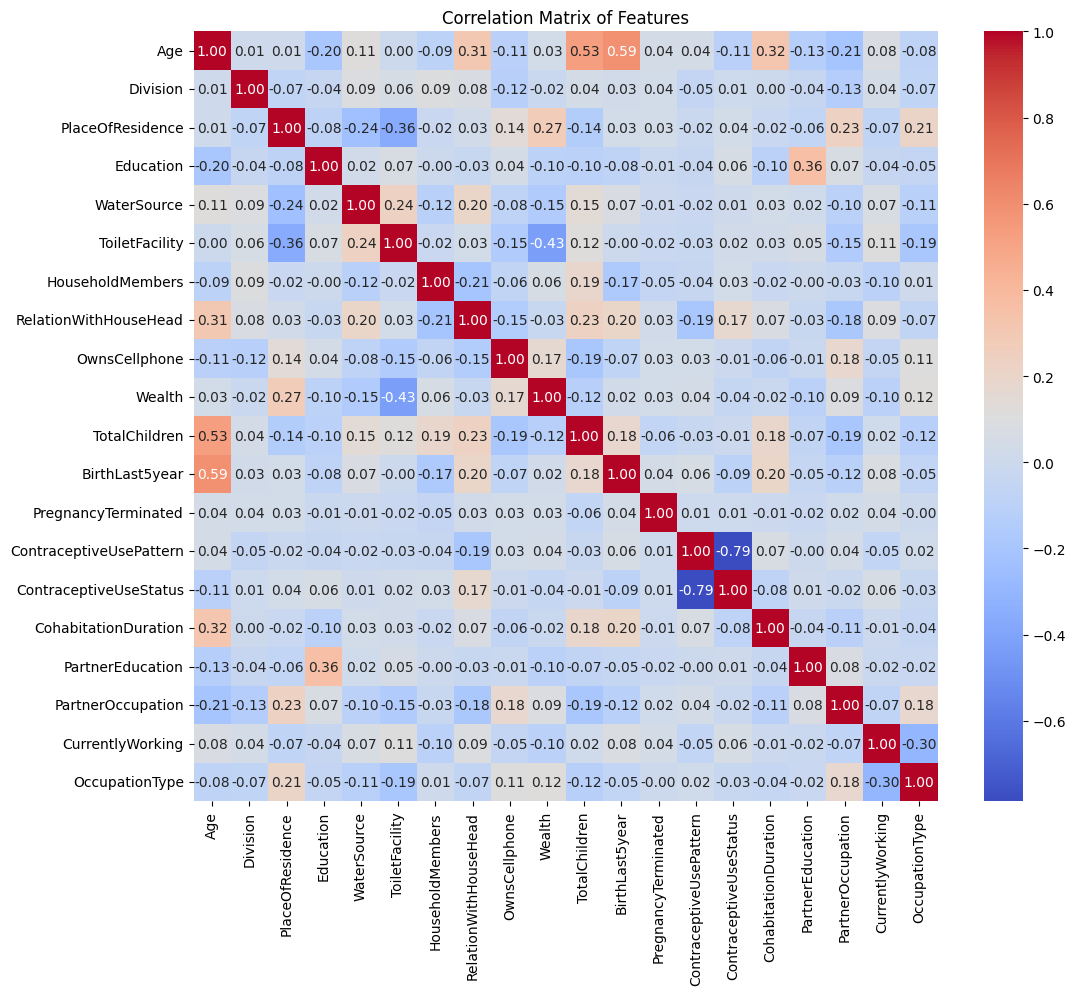

In [ ]:
# Calculate the correlation matrix
correlation_matrix = X_train.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()


##XGBoost with SHAP


In [ ]:
import xgboost as xgb

# Train XGBoost model
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)

# Get feature importance
feature_importance = xgb_model.feature_importances_
important_features = X_train.columns[np.argsort(feature_importance)[::-1]][:20]  # Select top 20

print("Top Features:", list(important_features))

Top Features: ['Wealth', 'OwnsCellphone', 'Age', 'PartnerOccupation', 'Division', 'CohabitationDuration', 'Education', 'OccupationType', 'TotalChildren', 'CurrentlyWorking', 'PregnancyTerminated', 'PlaceOfResidence', 'ToiletFacility', 'ContraceptiveUsePattern', 'WaterSource', 'BirthLast5year', 'ContraceptiveUseStatus', 'HouseholdMembers', 'RelationWithHouseHead', 'PartnerEducation']


In [ ]:
#XGBoost Classifier

from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.metrics import roc_auc_score

# Define search space
space = {
    'max_depth': hp.choice('max_depth', range(3, 10)),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'n_estimators': hp.choice('n_estimators', range(100, 500)),
    'subsample': hp.uniform('subsample', 0.5, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1)
}

# Define objective function
def objective(params):
    model = xgb.XGBClassifier(**params, eval_metric="auc", use_label_encoder=False)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    score = roc_auc_score(y_test, y_pred)
    return {'loss': -score, 'status': STATUS_OK}

# Run optimization
trials = Trials()
best_params = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Train final model with best parameters
best_model = xgb.XGBClassifier(**best_params, eval_metric="auc", use_label_encoder=False)
best_model.fit(X_train, y_train)

# Evaluate model
y_pred = best_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred)
print(f"Optimized XGBoost AUC Score: {auc_score:.4f}")

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [08:36:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  5%|▌         | 1/20 [00:01<00:25,  1.32s/trial, best loss: -0.7967775221243066]

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [08:36:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 10%|█         | 2/20 [00:01<00:13,  1.29trial/s, best loss: -0.8493039426016054]

...

 95%|█████████▌| 19/20 [00:12<00:00,  1.12trial/s, best loss: -0.9806205769854335]

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [08:37:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



100%|██████████| 20/20 [00:13<00:00,  1.50trial/s, best loss: -0.9806205769854335]


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [08:37:07] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Optimized XGBoost AUC Score: 0.9447


 99%|===================| 4612/4675 [00:44<00:00]       

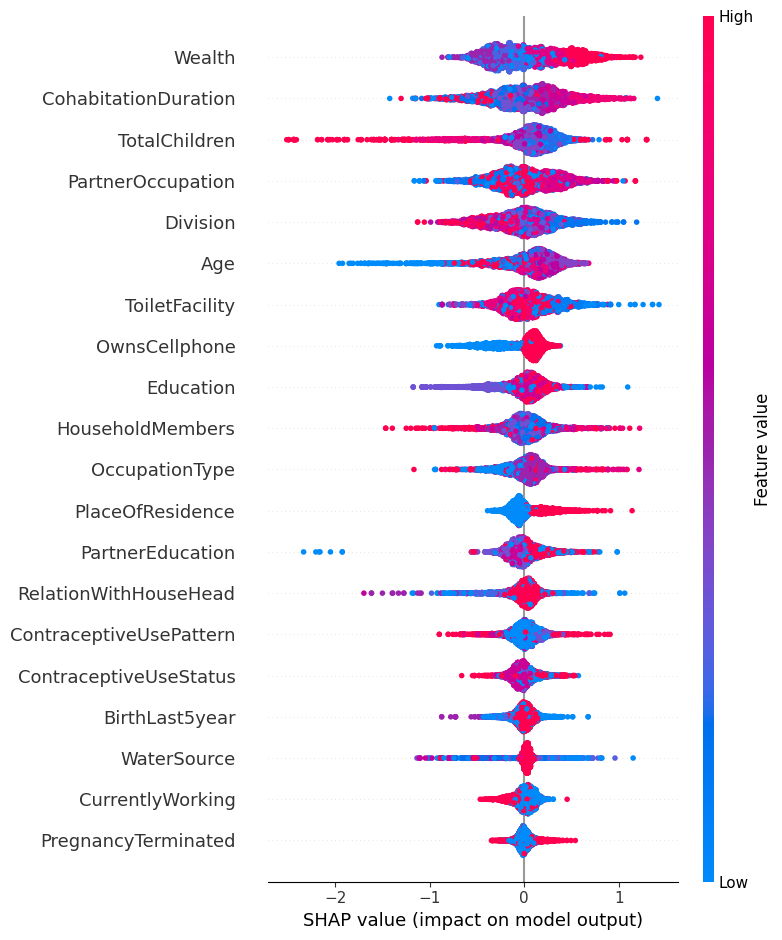

In [ ]:
import shap

# Explain model predictions
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test)

In [ ]:
df_final= df_dropped[['ToiletFacility', 'Wealth', 'PlaceOfResidence', 'PartnerOccupation', 'Division', 'OccupationType',
                      'OwnsCellphone', 'BirthLast5year', 'Age', 'TotalChildren', 'CurrentlyWorking',
                      'PregnancyTerminated', 'ContraceptiveUsePattern', 'WaterSource', 'Education',
                      'CohabitationDuration', 'ContraceptiveUseStatus']].copy()


df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23372 entries, 0 to 73234
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ToiletFacility           23372 non-null  int64  
 1   Wealth                   23372 non-null  int64  
 2   PlaceOfResidence         23372 non-null  int64  
 3   PartnerOccupation        23372 non-null  int64  
 4   Division                 23372 non-null  int64  
 5   OccupationType           23372 non-null  int64  
 6   OwnsCellphone            23372 non-null  int64  
 7   BirthLast5year           23372 non-null  int64  
 8   Age                      23372 non-null  int64  
 9   TotalChildren            23372 non-null  float64
 10  CurrentlyWorking         23372 non-null  int64  
 11  PregnancyTerminated      23372 non-null  int64  
 12  ContraceptiveUsePattern  23372 non-null  int64  
 13  WaterSource              23372 non-null  int64  
 14  Education                23

#Applying Machine Learning Models

In [ ]:
y= df_dropped[["Obesity"]].copy()

x_train, x_test, y_train, y_test = train_test_split(df_final, y, test_size=0.20, random_state =803)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((18697, 17), (4675, 17), (18697, 1), (4675, 1))

### Decision Tree

In [ ]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()

dtree.fit(x_train,y_train)
predictions = dtree.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=4))
print(confusion_matrix(y_test,predictions))

tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

specificity = tn / (tn + fp)
print("Specificity: %0.4f" % specificity)

y_pred_proba = dtree.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)


              precision    recall  f1-score   support

           0     0.9593    0.9490    0.9541      2903
           1     0.9179    0.9340    0.9259      1772

    accuracy                         0.9433      4675
   macro avg     0.9386    0.9415    0.9400      4675
weighted avg     0.9436    0.9433    0.9434      4675

[[2755  148]
 [ 117 1655]]
Specificity: 0.9490
AUC: 0.9446486043471803


### Random Forest

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100)

rfc.fit(x_train,y_train)
predictions = rfc.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=3))
print(confusion_matrix(y_test,predictions))

tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

specificity = tn / (tn + fp)

print("Specificity: %0.4f" % specificity)

y_pred_proba = rfc.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

           0      0.955     0.967     0.961      2903
           1      0.945     0.925     0.935      1772

    accuracy                          0.951      4675
   macro avg      0.950     0.946     0.948      4675
weighted avg      0.951     0.951     0.951      4675

[[2807   96]
 [ 133 1639]]
Specificity: 0.9669
AUC: 0.9907101628345862


### KNN

In [ ]:
#K- nearest neighbor
from sklearn.neighbors import KNeighborsClassifier
KN=KNeighborsClassifier()

x_train, x_test, y_train, y_test = train_test_split(df_final, y, test_size=0.20, random_state =803)
KN.fit(x_train,y_train)
predictions=KN.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=4))
print(confusion_matrix(y_test,predictions))

tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

specificity = tn / (tn + fp)

print("Specificity: %0.4f" % specificity)

y_pred_proba = KN.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


              precision    recall  f1-score   support

           0     0.8130    0.8340    0.8233      2903
           1     0.7160    0.6857    0.7005      1772

    accuracy                         0.7778      4675
   macro avg     0.7645    0.7598    0.7619      4675
weighted avg     0.7762    0.7778    0.7768      4675

[[2421  482]
 [ 557 1215]]
Specificity: 0.8340
AUC: 0.8656642851755287


### GaussianNB

In [ ]:
#GaussianNB
from sklearn.naive_bayes import GaussianNB
NB = GaussianNB()

x_train, x_test, y_train, y_test = train_test_split(df_final, y, test_size=0.20, random_state =803)
NB.fit(x_train, y_train)
predictions = NB.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=4))
print(confusion_matrix(y_test,predictions))

tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

specificity = tn / (tn + fp)

print("Specificity: %0.4f" % specificity)

y_pred_proba = NB.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

              precision    recall  f1-score   support

           0     0.7086    0.7496    0.7285      2903
           1     0.5468    0.4949    0.5195      1772

    accuracy                         0.6530      4675
   macro avg     0.6277    0.6222    0.6240      4675
weighted avg     0.6472    0.6530    0.6493      4675

[[2176  727]
 [ 895  877]]
Specificity: 0.7496
AUC: 0.6719515073143763


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


###Logistic Regression

In [ ]:
# logistic regression
from sklearn.linear_model import LogisticRegression
Lr = LogisticRegression()

x_train, x_test, y_train, y_test = train_test_split(df_final, y, test_size=0.20, random_state =803)
Lr.fit(x_train,y_train)
predictions = Lr.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=4))
print(confusion_matrix(y_test,predictions))

tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

specificity = tn / (tn + fp)

print("Specificity: %0.4f" % specificity)

y_pred_proba = Lr.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

              precision    recall  f1-score   support

           0     0.6858    0.8543    0.7609      2903
           1     0.6006    0.3589    0.4493      1772

    accuracy                         0.6665      4675
   macro avg     0.6432    0.6066    0.6051      4675
weighted avg     0.6535    0.6665    0.6428      4675

[[2480  423]
 [1136  636]]
Specificity: 0.8543
AUC: 0.6759685240379494


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


###Support Vector Machine

In [ ]:
#support vector machine
from sklearn.svm import LinearSVC
svm = LinearSVC()

x_train, x_test, y_train, y_test = train_test_split(df_final, y, test_size=0.20, random_state =803)
svm.fit(x_train,y_train)
y_predict = svm.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_predict,digits=4))
print(confusion_matrix(y_test,y_predict))

tn, fp, fn, tp = confusion_matrix(y_test, y_predict).ravel()

specificity = tn / (tn + fp)

print("Specificity: %0.4f" % specificity)

y_score = svm.decision_function(x_test)

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

              precision    recall  f1-score   support

           0     0.6857    0.8567    0.7617      2903
           1     0.6031    0.3567    0.4482      1772

    accuracy                         0.6672      4675
   macro avg     0.6444    0.6067    0.6050      4675
weighted avg     0.6544    0.6672    0.6429      4675

[[2487  416]
 [1140  632]]
Specificity: 0.8567
AUC: 0.6756882037652339


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 130.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-c

In [ ]:
#XGBoost Classifier

from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, log_loss

# Define search space
space = {
    'max_depth': hp.choice('max_depth', range(3, 10)),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'n_estimators': hp.choice('n_estimators', range(100, 500)),
    'subsample': hp.uniform('subsample', 0.5, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1)
}

# Define objective function
def objective(params):
    model = xgb.XGBClassifier(**params, eval_metric="auc", use_label_encoder=False)
    model.fit(x_train, y_train)
    y_pred = model.predict_proba(x_test)[:, 1]
    score = roc_auc_score(y_test, y_pred)
    return {'loss': -score, 'status': STATUS_OK}

# Run optimization
trials = Trials()
best_params = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Train final model with best parameters
best_model = xgb.XGBClassifier(**best_params, eval_metric="auc", use_label_encoder=False)
best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)  # For metrics requiring hard predictions
y_pred_proba = best_model.predict_proba(x_test)[:, 1]  # For AUC and log loss

# Calculate metrics
xgb_auc_score = roc_auc_score(y_test, y_pred_proba)
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_precision = precision_score(y_test, y_pred)
xgb_recall = recall_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_log_loss = log_loss(y_test, y_pred_proba)


# Print results
print(f"Optimized XGBoost Metrics:")
print(f"  ROC AUC Score: {xgb_auc_score:.4f}")
print(f"  Accuracy: {xgb_accuracy:.4f}")
print(f"  Precision: {xgb_precision:.4f}")
print(f"  Recall: {xgb_recall:.4f}")
print(f"  F1 Score: {xgb_f1:.4f}")
print(f"  Log Loss: {xgb_log_loss:.4f}")

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [08:57:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  5%|▌         | 1/20 [00:00<00:11,  1.63trial/s, best loss: -0.8397383534896958]

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [08:57:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 10%|█         | 2/20 [00:01<00:11,  1.62trial/s, best loss: -0.9665235970572981]

...

100%|██████████| 20/20 [00:12<00:00,  1.63trial/s, best loss: -0.975262707917162]

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [08:57:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



100%|██████████| 20/20 [00:12<00:00,  1.56trial/s, best loss: -0.975262707917162]


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [08:57:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Optimized XGBoost Metrics:
  ROC AUC Score: 0.9267
  Accuracy: 0.8588
  Precision: 0.8374
  Recall: 0.7788
  F1 Score: 0.8070
  Log Loss: 0.3513


In [ ]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

x_train, x_test, y_train, y_test = train_test_split(df_final, y, test_size=0.20, random_state =803)


# Scale numerical features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [ ]:
# Define MLP model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report
import numpy as np


mlp_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',  # Accuracy
        tf.keras.metrics.AUC(name='auc'),  # Area Under the ROC Curve
        tf.keras.metrics.Precision(name='precision'),  # Precision
        tf.keras.metrics.Recall(name='recall')  # Sensitivity (Recall)
    ]
)

# Train model
history= mlp_model.fit(x_train_scaled, y_train, validation_data=(x_test_scaled, y_test), epochs=50, batch_size=32, verbose=1)

# Evaluate model
results = mlp_model.evaluate(x_test_scaled, y_test, verbose=0)
metrics_names = ['loss', 'accuracy', 'auc', 'precision', 'recall']
for name, value in zip(metrics_names, results):
    print(f"{name.capitalize()}: {value:.4f}")

# Predict probabilities and convert to binary predictions
y_pred_prob = mlp_model.predict(x_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Threshold at 0.5 for binary classification


f1 = f1_score(y_test, y_pred)

print(f"F1-Score: {f1:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


585/585 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5718 - auc: 0.5682 - loss: 0.7676 - precision: 0.4427 - recall: 0.4242 - val_accuracy: 0.6661 - val_auc: 0.6818 - val_loss: 0.6151 - val_precision: 0.5904 - val_recall: 0.3888
Epoch 2/50
585/585 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6379 - auc: 0.6424 - loss: 0.6444 - precision: 0.5370 - recall: 0.3656 - val_accuracy: 0.6725 - val_auc: 0.6917 - val_loss: 0.6097 - val_precision: 0.6147 - val_recall: 0.3646
Epoch 3/50
585/585 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6533 - auc: 0.6652 - loss: 0.6286 - precision: 0.5885 - recall: 0.3524 - val_accuracy: 0.6742 - val_auc: 0.6971 - val_loss: 0.6069 - val_precision: 0.6099 - val_recall: 0.3900
Epoch 4/50
585/585 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6571 - auc: 0.6736 - loss: 0.6234 - precision: 0.5953 - recall: 0.3671 - val_accuracy: 0.6744 - val_auc: 0.7012 - val_loss: 0.6044 - val_precision: 0.6128 - val_recall: 0.3832
Epoch 5/50
585/585 ━━━━━━━━━━━━━━━━━━━━ 3s 

Available keys in history: dict_keys(['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall'])


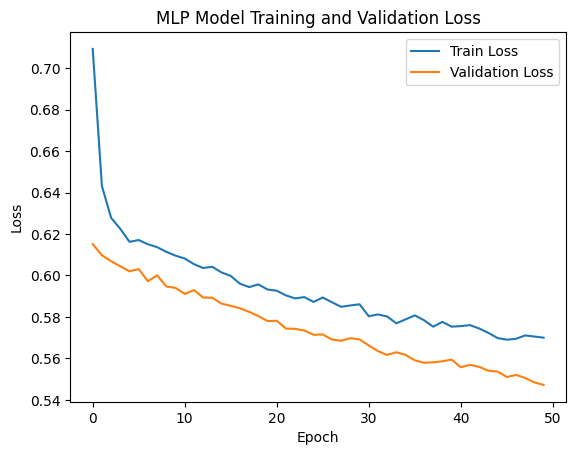

In [ ]:
import matplotlib.pyplot as plt

print(f"Available keys in history: {history.history.keys()}")

# Plotting the training loss and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MLP Model Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()


In [ ]:
# Convert data for TabNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
x_train, x_test, y_train, y_test = train_test_split(df_final, y, test_size=0.20, random_state =42)

x_train_np, x_test_np = x_train.values, x_test.values
y_train_np, y_test_np = y_train.values.flatten(), y_test.values.flatten() #flatten the 2d arrays

# Define TabNet model
tabnet_model = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type="entmax"
)

# Train TabNet
tabnet_model.fit(
    x_train_np, y_train_np,
    eval_set=[(x_test_np, y_test_np)],
    eval_metric=['auc'],
    max_epochs=50,
    patience=10
)

# Evaluate TabNet
tabnet_pred_probs = tabnet_model.predict_proba(x_test_np)[:, 1]
tabnet_auc = roc_auc_score(y_test_np, tabnet_pred_probs)
print(f"TabNet AUC Score: {tabnet_auc:.4f}")

# Convert probabilities to binary predictions using 0.5 threshold
tabnet_preds = (tabnet_pred_probs > 0.5).astype(int)

# Compute additional metrics using scikit-learn
accuracy = accuracy_score(y_test_np, tabnet_preds)
precision = precision_score(y_test_np, tabnet_preds)
recall = recall_score(y_test_np, tabnet_preds)  # Sensitivity
f1 = f1_score(y_test_np, tabnet_preds)

# Print metrics
print("\nScikit-learn Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test_np, tabnet_preds))

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.70575 | val_0_auc: 0.53818 |  0:00:00s
epoch 1  | loss: 0.64014 | val_0_auc: 0.55156 |  0:00:01s
epoch 2  | loss: 0.62834 | val_0_auc: 0.58649 |  0:00:02s
epoch 3  | loss: 0.62075 | val_0_auc: 0.59126 |  0:00:03s
epoch 4  | loss: 0.61433 | val_0_auc: 0.61274 |  0:00:04s
epoch 5  | loss: 0.61095 | val_0_auc: 0.6499  |  0:00:05s
epoch 6  | loss: 0.60346 | val_0_auc: 0.65217 |  0:00:06s
epoch 7  | loss: 0.60113 | val_0_auc: 0.66509 |  0:00:07s
epoch 8  | loss: 0.59967 | val_0_auc: 0.67251 |  0:00:07s
epoch 9  | loss: 0.59692 | val_0_auc: 0.67309 |  0:00:08s
epoch 10 | loss: 0.59424 | val_0_auc: 0.69291 |  0:00:09s
epoch 11 | loss: 0.58658 | val_0_auc: 0.69387 |  0:00:10s
epoch 12 | loss: 0.58652 | val_0_auc: 0.69436 |  0:00:11s
epoch 13 | loss: 0.58451 | val_0_auc: 0.71396 |  0:00:12s
epoch 14 | loss: 0.58101 | val_0_auc: 0.71355 |  0:00:13s
epoch 15 | loss: 0.57386 | val_0_auc: 0.71824 |  0:00:14s
epoch 16 | loss: 0.57159 | val_0_auc: 0.72757 |  0:00:14s
epoch 17 | los

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet AUC Score: 0.7987

Scikit-learn Metrics:
Accuracy: 0.7316
Precision: 0.6635
Recall (Sensitivity): 0.6183
F1-Score: 0.6401

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.80      0.79      2870
           1       0.66      0.62      0.64      1805

    accuracy                           0.73      4675
   macro avg       0.72      0.71      0.71      4675
weighted avg       0.73      0.73      0.73      4675



In [ ]:
print(f"XGBoost AUC: {auc_score:.4f}")
print(f"MLP AUC: {mlp_auc:.4f}")
print(f"TabNet AUC: {tabnet_auc:.4f}")

XGBoost AUC: 0.9447
MLP AUC: 0.7740
TabNet AUC: 0.7987


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Train XGBoost (already done)
xgb_preds_train = best_model.predict_proba(x_train)[:, 1]
xgb_preds_test = best_model.predict_proba(x_test)[:, 1]

# Train MLP (already done)
mlp_preds_train = mlp_model.predict(x_train_scaled).flatten()
mlp_preds_test = mlp_model.predict(x_test_scaled).flatten()

# Train TabNet (already done)
tabnet_preds_train = tabnet_model.predict_proba(x_train.values)[:, 1]
tabnet_preds_test = tabnet_model.predict_proba(x_test.values)[:, 1]

# Stack predictions (new feature matrix for Meta-Model)
stacked_train = np.column_stack((xgb_preds_train, mlp_preds_train, tabnet_preds_train))
stacked_test = np.column_stack((xgb_preds_test, mlp_preds_test, tabnet_preds_test))

585/585 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step


In [ ]:
# Train Meta-Learner
meta_learner = LogisticRegression()
meta_learner.fit(stacked_train, y_train)

# Predict final probabilities
stacked_preds = meta_learner.predict_proba(stacked_test)[:, 1]

# Evaluate Stacking Model
stacked_auc = roc_auc_score(y_test, stacked_preds)
print(f"Stacking Model AUC Score: {stacked_auc:.4f}")

Stacking Model AUC Score: 0.9741


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# Train Meta-Learner
meta_model = RandomForestClassifier()
meta_model.fit(stacked_train, y_train)

# Predict probabilities and binary outcomes
meta_pred_probs = meta_model.predict_proba(stacked_test)[:, 1]  # Probabilities for positive class
meta_preds = (meta_pred_probs > 0.5).astype(int)  # Binary predictions with 0.5 threshold

# Compute evaluation metrics
meta_auc = roc_auc_score(y_test, meta_pred_probs)
meta_accuracy = accuracy_score(y_test, meta_preds)
meta_precision = precision_score(y_test, meta_preds)
meta_recall = recall_score(y_test, meta_preds)  # Sensitivity
meta_f1 = f1_score(y_test, meta_preds)

# Print metrics
print(f"Stacked Model AUC Score: {meta_auc:.4f}")
print("\nScikit-learn Metrics:")
print(f"Accuracy: {meta_accuracy:.4f}")
print(f"Precision: {meta_precision:.4f}")
print(f"Recall (Sensitivity): {meta_recall:.4f}")
print(f"F1-Score: {meta_f1:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, meta_preds))

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Stacked Model AUC Score: 0.9822

Scikit-learn Metrics:
Accuracy: 0.9373
Precision: 0.9163
Recall (Sensitivity): 0.9219
F1-Score: 0.9191

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2870
           1       0.92      0.92      0.92      1805

    accuracy                           0.94      4675
   macro avg       0.93      0.93      0.93      4675
weighted avg       0.94      0.94      0.94      4675

